# Apresentacao: Analise Global de Mudancas Climaticas com Spark

Autores: Rodrigo Macedo e Gabriel Peres.

Este notebook e o apoio executavel do principal material de avaliacao do trabalho passado pelo professor. O PDF explica o projeto em formato de relatorio; este notebook mostra o mesmo processo rodando passo a passo, com codigo, resultados, graficos e pontos de verificacao.

A ideia central e simples:

1. Os CSVs entram como DataFrames Spark.
2. O Spark divide os DataFrames em particoes.
3. Transformacoes como `filter`, `withColumn`, `groupBy`, `join` e `Window` montam um plano logico.
4. Acoes como `count`, `show` e `write` disparam jobs.
5. Os jobs viram stages, os stages viram tasks, e as tasks rodam nos workers.
6. Os resultados pequenos saem como CSV, Parquet e graficos.

O foco da apresentacao e mostrar o projeto completo: quais dados foram usados, por que cada tratamento foi feito, onde o Spark divide o processamento, como cada pergunta foi respondida e como validamos Docker local, 2 PCs e Spark UI.

Este notebook e coeso com `README.md`, `RELATORIO.md`, `relatorio_latex/main.tex`, `PLANO_DIVISAO_APRESENTACAO.md`, `SABER_ROGER.md` e `SABER_GABRIEL.md`.


## 1. Como usar este notebook na apresentacao

Use o notebook como roteiro executavel. O PDF e o material principal de avaliacao; o notebook serve para demonstrar ao vivo que o processo descrito no relatorio existe no codigo e roda de ponta a ponta.

A apresentacao pode seguir esta ordem:

| Bloco | O que mostrar | Por que mostrar |
|---|---|---|
| Contexto | Trabalho pedido, bases e perguntas | Situa o professor antes do codigo |
| Arquitetura | Docker, master, workers, driver e 2 PCs | Mostra que nao e script Python comum |
| Fluxo dos arquivos | `main.py`, `cleaning.py`, `analytics.py` | Mostra onde cada etapa esta feita |
| Divisao | Particoes, `repartition`, `mapPartitionsWithIndex` | Prova como o Spark divide o dado |
| Pipeline | Leitura, limpeza, agregacao, join e cache | Mostra o caminho completo do dado |
| Q1 a Q8 | Uma pergunta por vez | Responde o enunciado sem pular logica |
| Spark UI | Workers, executors, jobs, stages, tasks, storage | Prova visual da distribuicao |
| Demo | Docker local e 2 PCs | Fecha com execucao real |

A fala deve sempre seguir o mesmo padrao:

```text
A pergunta pede X.
O dado bruto esta em Y.
A funcao que faz isso e Z.
O Spark divide por particoes e executa nos workers.
O resultado final e W.
```

Se uma decisao for arbitraria, como percentual de incerteza, anos de historico, numero de particoes ou proxy de minima e maxima, explique o criterio e o que mudaria se o valor fosse alterado.


## 2. Mapa dos arquivos do projeto

Esta tabela e importante porque o professor quer ver onde as etapas estao feitas.

| Arquivo | Funcao no projeto | O que defender na apresentacao |
|---|---|---|
| `Dockerfile` | Cria a imagem com Spark e dependencias Python | O ambiente fica reproduzivel |
| `docker-compose.yml` | Sobe master, dois workers e app local | Simula um cluster Spark em uma maquina |
| `scripts/setup_data.sh` | Extrai Kaggle e baixa CO2 da OWID | Prepara `data/raw` |
| `scripts/local_workers_raw.sh 2` | Roda demo com `data/sample` | Caminho seguro para apresentar rapido |
| `scripts/local_workers_raw.sh 2` | Roda dados reais com cache ligado e desligado | Gera resultados e comparativo de tempo |
| `scripts/pc1_start_raw.sh` | Sobe master no PC1 | Abre `spark://IP:7077` e UI em `http://IP:8080` |
| `scripts/pc2_worker_raw.sh` | Sobe worker no PC2 | Conecta o PC2 no master do PC1 |
| `scripts/pc1_benchmark_raw.sh` | Submete job ao cluster LAN | Envia `main.py` para execucao distribuida |
| `src/climate_spark/main.py` | Orquestra o pipeline completo | E o ponto de entrada da aplicacao |
| `src/climate_spark/io_utils.py` | Le e escreve dados | `read_csv` cria DataFrames Spark |
| `src/climate_spark/cleaning.py` | Limpa temperatura e CO2 | Datas, paises, coordenadas e incerteza |
| `src/climate_spark/analytics.py` | Responde Q1 a Q8 | Agregacoes, join, window functions e MLlib |
| `src/climate_spark/plotting.py` | Gera graficos finais | So usa resultados pequenos ja agregados |
| `RELATORIO.md` | Relatorio tecnico | Mesma narrativa deste notebook |
| `PLANO_DIVISAO_APRESENTACAO.md` | Divisao da fala | Ajuda a organizar Rodrigo e Gabriel |

Resumo para falar:

```text
O notebook nao cria uma segunda versao do projeto. Ele chama as mesmas funcoes do codigo final e explica cada etapa.
```


## 3. Arquitetura: Docker local e 2 PCs

### Modo Docker local

`docker-compose.yml` sobe quatro servicos:

| Servico | Papel |
|---|---|
| `spark-master` | Coordena o cluster Spark |
| `spark-worker-1` | Executa tasks |
| `spark-worker-2` | Executa tasks |
| `spark-app` | Container usado para rodar `spark-submit` |

A pasta do projeto e montada em `/app`. Por isso o codigo, os dados e as saidas ficam visiveis dentro dos containers.

```text
maquina local
  docker compose
    spark-master   porta 7077, UI em localhost:18080
    spark-worker-1 executa tasks
    spark-worker-2 executa tasks
    spark-app      envia o job com spark-submit
```

### Modo 2 PCs

No modo de dois computadores, o PC1 roda o master, um worker local e o driver do job. O PC2 roda outro worker conectado pelo IP do PC1.

```text
PC1
  master Spark em Docker
  worker local
  driver do job
  data/raw disponivel em /app/data/raw

PC2
  worker Spark em Docker
  data/raw disponivel em /app/data/raw

rede local
  spark://IP_DO_PC1:7077
```

Fluxo de comunicacao:

1. O driver inicia o job e conversa com o master Spark.
2. O master registra os workers vivos.
3. O driver cria o plano logico e fisico das operacoes.
4. O Spark quebra o plano em jobs, stages e tasks.
5. O master agenda tasks nos executors dos workers.
6. Os executors processam particoes e devolvem resultados intermediarios.
7. O driver coleta apenas resultados pequenos para tabela, grafico ou arquivo final.

| Componente | Papel no trabalho |
|---|---|
| Driver | Submete o job, cria a SparkSession e coordena as acoes |
| Master Spark | Agenda recursos e conhece os workers vivos |
| Worker | Oferece CPU e memoria ao cluster |
| Executor | Processo que executa tasks nas particoes |
| Spark UI | Mostra workers, executors, jobs, stages, tasks e duracao |

Ponto importante para defender:

```text
O projeto nao usa HDFS. Entao, no modo 2 PCs, os dados precisam existir nos dois PCs no mesmo caminho do container. O processamento e distribuido pelo Spark em particoes e tasks. Os arquivos ficam replicados nos nos para que os executors consigam ler `/app/data`.
```

Decisao tecnica: usar DataFrames em vez de RDD manual deixa o Spark otimizar filtros, agregacoes, joins e projeções pelo Catalyst. A conversao para pandas acontece somente depois de reduzir os dados para resultados pequenos usados em graficos.


## 4. Onde a divisao acontece

A divisao nao esta em uma funcao nossa chamada `dividir_dados`. A divisao e feita pelo Spark nas particoes dos DataFrames.

| Momento | Codigo | Como divide |
|---|---|---|
| Leitura | `spark.read.csv(...)` em `read_csv` | Cria DataFrames com particoes |
| Agregacao | `groupBy(...).agg(...)` | Redistribui linhas por chave |
| Join | `join(..., [country_norm, year])` | Coloca chaves iguais na mesma particao |
| Window | `Window.partitionBy("Country")` | Calcula dentro de grupos logicos |
| Reparticao explicita | `repartition(8, "Country")` | Forca 8 particoes usando pais como chave |
| Cache | `cache()` | Guarda particoes nos executors |
| Acao | `count`, `show`, `write` | Dispara jobs, stages e tasks |

Como explicar:

```text
DataFrame e uma descricao distribuida do dado. Ele tem particoes. Quando chamamos uma acao, o Spark transforma o plano em jobs. Cada job e dividido em stages, e cada stage em tasks. Cada task processa uma particao em um worker.
```

Termos que aparecem em `explain(True)`:

| Termo | Significado |
|---|---|
| `Scan csv` | Leitura dos CSVs |
| `Exchange` | Redistribuicao de dados entre particoes |
| `HashAggregate` | Agregacao distribuida |
| `SortMergeJoin` | Join distribuido |
| `Window` | Calculo com janela |
| `InMemoryTableScan` | Leitura a partir de cache |

Ver workers vivos na Spark UI prova que o cluster esta conectado. Para provar que a aplicacao usou os workers, mostre tambem executors, tasks, hosts e stages durante o job.


## 5. Preparacao e imports

Esta celula prepara o notebook para usar o pacote real do projeto.

Como:

1. Descobre a raiz do projeto.
2. Adiciona `src` no `sys.path`.
3. Cria uma sessao Spark.
4. Define se vamos usar `sample` ou `raw`.

Por que:

O notebook deve explicar e executar o mesmo codigo do trabalho, sem copiar a logica para outro lugar.


In [1]:
from pathlib import Path
import os
import socket
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_MODE = os.environ.get("DATA_MODE", "sample")
SPARK_MASTER = os.environ.get("SPARK_MASTER", "local[2]")
OUTPUT_DIR = PROJECT_ROOT / "output_notebook"

print("project root:", PROJECT_ROOT)
print("data mode:", DATA_MODE)
print("spark master:", SPARK_MASTER)
print("host:", socket.gethostname())


project root: /home/roger/uel/sistemas-distribuidos/spark
data mode: raw
spark master: local[2]
host: riri


## 5.1 Parametros faceis de mudar

Esta secao existe para a apresentacao ao vivo. Se o professor pedir para mudar um percentual, uma cidade, um pais, o tamanho de ranking ou o numero de particoes, mexa aqui primeiro.

| Variavel | Onde afeta | Se aumentar | Se diminuir |
|---|---|---|---|
| `DATA_MODE` | Leitura dos dados | `raw` usa dados reais e demora mais | `sample` roda rapido para demonstrar |
| `UNCERTAINTY_RATIO` | Q5 no notebook | Marca menos registros como alta incerteza | Marca mais registros como alta incerteza |
| `PARTITION_COUNT` | Prova de distribuicao | Cria mais tasks e pode mostrar mais paralelismo | Cria menos tasks e simplifica a UI |
| `TOP_N_PER_CONTINENT` | Q2 | Mostra mais anos por continente | Mostra uma tabela menor |
| `RISKIEST_CITY_LIMIT` | Q3 | Mostra mais cidades | Mostra menos cidades |
| `FORECAST_YEARS_AHEAD` | Q8 | Preve mais anos futuros | Preve menos anos futuros |
| `FORECAST_HISTORY_YEARS` | Q8 | Usa mais historico no treino | Usa uma janela mais recente |
| `FORECAST_CITY` e `FORECAST_COUNTRY` | Q8 | Troca a cidade e pais da previsao | Troca a cidade e pais da previsao |

Regra pratica: se aumentar um limite, a tabela tende a ficar mais restrita ou mais longa dependendo da variavel; se diminuir, o efeito vai no sentido contrario. Para Q5 especificamente, se aumentar `UNCERTAINTY_RATIO`, menos registros sao marcados; se diminuir, mais registros sao marcados.

Ponto importante: `clean_city_temperatures` no codigo do projeto usa a regra oficial de 10 por cento. Para experimentar outro percentual durante a apresentacao, o notebook cria `high_uncertainty_custom`. Assim da para iterar sem mudar o codigo final do trabalho.


In [2]:
UNCERTAINTY_RATIO = float(os.environ.get("UNCERTAINTY_RATIO", "0.10"))
PARTITION_COUNT = int(os.environ.get("PARTITION_COUNT", "8"))
TOP_N_PER_CONTINENT = int(os.environ.get("TOP_N_PER_CONTINENT", "10"))
RISKIEST_CITY_LIMIT = int(os.environ.get("RISKIEST_CITY_LIMIT", "20"))
FORECAST_YEARS_AHEAD = int(os.environ.get("FORECAST_YEARS_AHEAD", "5"))
FORECAST_HISTORY_YEARS = int(os.environ.get("FORECAST_HISTORY_YEARS", "20"))
FORECAST_CITY = os.environ.get("FORECAST_CITY", "Rio De Janeiro")
FORECAST_COUNTRY = os.environ.get("FORECAST_COUNTRY", "Brazil")

print("uncertainty ratio:", UNCERTAINTY_RATIO)
print("partition count:", PARTITION_COUNT)
print("top n per continent:", TOP_N_PER_CONTINENT)
print("riskiest city limit:", RISKIEST_CITY_LIMIT)
print("forecast:", FORECAST_CITY, FORECAST_COUNTRY, FORECAST_YEARS_AHEAD, FORECAST_HISTORY_YEARS)


uncertainty ratio: 0.1
partition count: 8
top n per continent: 10
riskiest city limit: 20
forecast: Rio De Janeiro Brazil 5 20


In [3]:
from climate_spark.main import build_spark
from climate_spark.config import CO2_FILE, GLOBAL_TEMPERATURE_FILE, TEMPERATURE_CITY_FILE
from climate_spark.io_utils import ensure_dirs, read_csv, write_parquet_sample, write_result
from climate_spark.cleaning import clean_city_temperatures, clean_co2, clean_global_temperatures, filter_reliable_temperatures
from climate_spark.analytics import (
    acceleration_ranking,
    annual_city_temperatures,
    annual_country_temperatures,
    co2_temperature_correlation,
    decade_country_temperatures,
    forecast_temperature,
    global_decade_trend,
    high_uncertainty_summary,
    hottest_years_by_continent,
    join_temperature_co2,
    riskiest_cities,
    tropical_min_max_correlation_df,
)
from climate_spark.plotting import plot_co2_temperature_scatter, plot_global_decade_temperature
from pyspark.sql import functions as F

spark = build_spark(SPARK_MASTER)
ensure_dirs(OUTPUT_DIR / "results", OUTPUT_DIR / "plots", OUTPUT_DIR / "parquet")

print("Spark master real:", spark.sparkContext.master)
print("Paralelismo padrao:", spark.sparkContext.defaultParallelism)


Spark master real: local[2]
Paralelismo padrao: 2


## 6. Leitura dos dados com Spark

Arquivos usados:

| Arquivo | Origem | Para que serve |
|---|---|---|
| `GlobalLandTemperaturesByCity.csv` | Kaggle Berkeley Earth | Base principal de temperatura por cidade e mes |
| `GlobalTemperatures.csv` | Kaggle Berkeley Earth | Base global com colunas de min e max, mantida para contexto |
| `owid-co2-data.csv` | Our World in Data | Base de CO2 por pais e ano |

Como:

`read_csv` chama `spark.read.csv(..., header=True, inferSchema=True)`.

Por que:

A leitura precisa acontecer no Spark para que os dados entrem como DataFrames particionados. Se lessemos com pandas aqui, perderiamos a demonstracao distribuida.


In [4]:
input_dir = PROJECT_ROOT / "data" / DATA_MODE

city_raw = read_csv(spark, input_dir / TEMPERATURE_CITY_FILE)
global_raw = read_csv(spark, input_dir / GLOBAL_TEMPERATURE_FILE)
co2_raw = read_csv(spark, input_dir / CO2_FILE)

print("Particoes temperatura cidade:", city_raw.rdd.getNumPartitions())
print("Particoes temperatura global:", global_raw.rdd.getNumPartitions())
print("Particoes CO2:", co2_raw.rdd.getNumPartitions())

city_raw.printSchema()
city_raw.show(5, truncate=False)


Particoes temperatura cidade: 4
Particoes temperatura global: 1
Particoes CO2: 2
root
 |-- dt: date (nullable = true)
 |-- AverageTemperature: double (nullable = true)
 |-- AverageTemperatureUncertainty: double (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)

+----------+------------------+-----------------------------+-----+-------+--------+---------+
|dt        |AverageTemperature|AverageTemperatureUncertainty|City |Country|Latitude|Longitude|
+----------+------------------+-----------------------------+-----+-------+--------+---------+
|1743-11-01|6.068             |1.7369999999999999           |Århus|Denmark|57.05N  |10.33E   |
|1743-12-01|NULL              |NULL                         |Århus|Denmark|57.05N  |10.33E   |
|1744-01-01|NULL              |NULL                         |Århus|Denmark|57.05N  |10.33E   |
|1744-02-01|NULL              |NULL         

### Exemplo pequeno: o que `groupBy` faz

Antes de olhar milhoes de linhas, este exemplo mostra a ideia. O Spark pega linhas repetidas de um mesmo pais e ano, agrupa pela chave e calcula a media.

Como:

`groupBy("Country", "year").avg("AverageTemperature")`

Por que:

A base de temperatura vem por cidade e mes. Para cruzar com CO2, precisamos chegar em pais e ano.


In [5]:
exemplo_temperatura = spark.createDataFrame(
    [
        ("Brazil", 2000, 22.1),
        ("Brazil", 2000, 23.0),
        ("Brazil", 2001, 22.8),
        ("France", 2000, 11.2),
    ],
    ["Country", "year", "AverageTemperature"],
)

exemplo_temperatura.groupBy("Country", "year").avg("AverageTemperature").show()


+-------+----+-----------------------+
|Country|year|avg(AverageTemperature)|
+-------+----+-----------------------+
| Brazil|2000|                  22.55|
| Brazil|2001|                   22.8|
| France|2000|                   11.2|
+-------+----+-----------------------+



## 7. Limpeza dos dados, como e por que

A limpeza esta em `src/climate_spark/cleaning.py`.

### Temperatura por cidade

Funcao: `clean_city_temperatures(city_raw)`

| Transformacao | Como | Por que |
|---|---|---|
| Converter data | `to_date(dt)` | Permite extrair ano, mes e decada |
| Criar ano, mes, decada | `year`, `month`, `decade` | Facilita agregacoes temporais |
| Remover temperatura nula | `isNotNull` | Media sem valor nao pode entrar no calculo |
| Filtrar temperatura absurda | `between(-90, 70)` | Remove erros fisicos grosseiros |
| Converter coordenadas | regex em latitude e longitude | Necessario para zonas tropicais |
| Normalizar pais | `country_norm` | Necessario para join com CO2 |
| Calcular incerteza alta | media historica por cidade | Marca registros de baixa confianca |

### CO2

Funcao: `clean_co2(co2_raw)`

| Transformacao | Como | Por que |
|---|---|---|
| Converter ano e CO2 | `cast` | Permite calculos numericos |
| Filtrar ano >= 1900 | `year >= 1900` | Alinha com periodo moderno |
| Remover agregados | remove `World`, `Asia`, `Europe` e similares | O join e por pais, nao por continente |
| Criar `country_norm` | normalizacao de nomes | Chave comum para o join |


In [6]:
city_clean = clean_city_temperatures(city_raw)
global_clean = clean_global_temperatures(global_raw)
co2_clean = clean_co2(co2_raw)
reliable_city = filter_reliable_temperatures(city_clean)

print("Colunas apos limpeza de temperatura:")
print(city_clean.columns)

city_clean.select(
    "dt",
    "date",
    "year",
    "month",
    "decade",
    "City",
    "Country",
    "country_norm",
    "AverageTemperature",
    "AverageTemperatureUncertainty",
    "latitude_value",
    "longitude_value",
    "high_uncertainty",
).show(10, truncate=False)


Colunas apos limpeza de temperatura:
['City', 'Country', 'dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Latitude', 'Longitude', 'date', 'year', 'month', 'decade', 'latitude_value', 'longitude_value', 'country_norm', 'historical_avg_temperature', 'uncertainty_threshold', 'high_uncertainty']
+----------+----------+----+-----+------+-----+-------+------------+-------------------+-----------------------------+--------------+---------------+----------------+
|dt        |date      |year|month|decade|City |Country|country_norm|AverageTemperature |AverageTemperatureUncertainty|latitude_value|longitude_value|high_uncertainty|
+----------+----------+----+-----+------+-----+-------+------------+-------------------+-----------------------------+--------------+---------------+----------------+
|1743-11-01|1743-11-01|1743|11   |1740  |Århus|Denmark|Denmark     |6.068              |1.7369999999999999           |57.05         |10.33          |true            |
|1744-04-01|1744-04-01|174

## 8. Prova de distribuicao: particoes, hosts e tasks

Esta e a parte que responde diretamente: onde esta a divisao e como ela acontece.

A funcao abaixo nao divide os dados. Ela apenas entra em cada particao criada pelo Spark e registra:

| Campo | O que mostra |
|---|---|
| `partition` | Numero da particao Spark |
| `host` | Maquina ou container que processou a particao |
| `rows` | Quantas linhas passaram naquela particao |

A divisao explicita acontece em `repartition(8, "Country")`. O Spark reorganiza as linhas por pais em 8 particoes. Quando chamamos `mapPartitionsWithIndex`, cada particao vira trabalho para uma task.

No modo 2 PCs, o ideal e aparecerem hosts diferentes. Se aparecer um unico host, a explicacao correta e: o codigo esta distribuido em particoes, mas esta execucao especifica rodou em um unico host ou um unico executor visivel.


In [7]:
def inspect_partition(index, rows):
    count = 0
    for _ in rows:
        count += 1
    yield index, socket.gethostname(), count


# Com PARTITION_COUNT = 8, isto equivale a repartition(8, "Country").
partitioned_city = city_clean.repartition(PARTITION_COUNT, "Country")

print("Particoes antes:", city_clean.rdd.getNumPartitions())
print("Particoes depois:", partitioned_city.rdd.getNumPartitions())
print("Paralelismo padrao:", spark.sparkContext.defaultParallelism)

partition_evidence = (
    partitioned_city
    .rdd
    .mapPartitionsWithIndex(inspect_partition)
    .toDF(["partition", "host", "rows"])
)

partition_evidence.orderBy("host", "partition").show(truncate=False)


Particoes antes: 4
Particoes depois: 8
Paralelismo padrao: 2
+---------+----+-------+
|partition|host|rows   |
+---------+----+-------+
|0        |riri|563280 |
|1        |riri|345500 |
|2        |riri|677270 |
|3        |riri|3251438|
|4        |riri|638753 |
|5        |riri|1562505|
|6        |riri|780933 |
|7        |riri|415403 |
+---------+----+-------+



### Exemplo pequeno: join por chave comum

A temperatura e mensal por cidade. O CO2 e anual por pais. Antes do join, a temperatura precisa virar pais e ano.

Como:

1. Temperatura limpa vira `annual_country`.
2. CO2 limpo ja tem `country_norm` e `year`.
3. O join usa `country_norm` e `year`.

Por que:

Join so faz sentido quando as duas tabelas estao na mesma granularidade. Aqui a granularidade final e pais por ano.


In [8]:
temperatura_exemplo = spark.createDataFrame(
    [("Brazil", 2000, 22.55), ("France", 2000, 11.20)],
    ["country_norm", "year", "avg_temperature"],
)

co2_exemplo = spark.createDataFrame(
    [("Brazil", 2000, 327.5), ("France", 2000, 373.1)],
    ["country_norm", "year", "co2"],
)

temperatura_exemplo.join(co2_exemplo, ["country_norm", "year"], "inner").show()


+------------+----+---------------+-----+
|country_norm|year|avg_temperature|  co2|
+------------+----+---------------+-----+
|      Brazil|2000|          22.55|327.5|
|      France|2000|           11.2|373.1|
+------------+----+---------------+-----+



## 9. Cruzamento entre temperatura e CO2

Funcoes usadas:

| Funcao | Arquivo | Papel |
|---|---|---|
| `annual_country_temperatures` | `analytics.py` | Agrega temperatura por pais e ano |
| `annual_city_temperatures` | `analytics.py` | Agrega temperatura por cidade e ano |
| `join_temperature_co2` | `analytics.py` | Cruza temperatura e CO2 por `country_norm` e `year` |

Como:

`annual_country_temperatures` faz `groupBy("country_norm", "Country", "year")`. Depois `join_temperature_co2` usa `join(co2_df, ["country_norm", "year"], "inner")`.

Por que:

A pergunta 6 exige cruzar bases diferentes. O desafio e compatibilizar cidade por mes com pais por ano.


In [9]:
annual_country = annual_country_temperatures(reliable_city)
annual_city = annual_city_temperatures(reliable_city)
joined = join_temperature_co2(annual_country, co2_clean)

print("Temperatura anual por pais")
annual_country.show(5, truncate=False)

print("Join temperatura + CO2")
joined.show(10, truncate=False)

print("Particoes do join:", joined.rdd.getNumPartitions())


Temperatura anual por pais
+-------------+-------------+----+------------------+
|country_norm |Country      |year|avg_temperature   |
+-------------+-------------+----+------------------+
|United States|United States|1872|17.02126272123894 |
|Kazakhstan   |Kazakhstan   |1934|3.920219512195121 |
|Kazakhstan   |Kazakhstan   |1983|6.812698324022346 |
|Malaysia     |Malaysia     |1887|25.544440104166682|
|Venezuela    |Venezuela    |1828|25.219670454545465|
+-------------+-------------+----+------------------+
only showing top 5 rows

Join temperatura + CO2
+----------+------------+----+------------------+------------------+-------------------+------------------+
|Country   |country_norm|year|avg_temperature   |co2               |co2_per_capita     |total_ghg         |
+----------+------------+----+------------------+------------------+-------------------+------------------+
|Kazakhstan|Kazakhstan  |1934|3.920219512195121 |19.012653350830078|3.369899034500122  |61.5846061706543  |
|Kazakh

## 10. Cache e plano fisico

Cache esta em `main.py`, no modo `--cache on`.

DataFrames reutilizados:

- `city_clean`
- `global_clean`
- `co2_clean`
- `reliable_city`
- `annual_country`
- `annual_city`
- `joined`

Como:

`df.cache()` marca o DataFrame para ficar na memoria dos executors. A chamada so materializa quando fazemos uma acao, por exemplo `count()`.

Por que:

As perguntas reutilizam as mesmas bases limpas. Sem cache, o Spark pode recalcular etapas anteriores. Com cache, ele reaproveita particoes ja calculadas.

O `explain(True)` mostra o plano. Procure por `Exchange`, `HashAggregate`, `SortMergeJoin`, `Window` e `InMemoryTableScan`.


In [10]:
city_clean = city_clean.cache()
co2_clean = co2_clean.cache()
reliable_city = reliable_city.cache()
annual_country = annual_country.cache()
annual_city = annual_city.cache()
joined = joined.cache()

city_clean.count()
co2_clean.count()
reliable_city.count()
annual_country.count()
annual_city.count()
joined.count()

q1_plan_demo = global_decade_trend(reliable_city)
q1_plan_demo.explain(True)


== Parsed Logical Plan ==
'Project [decade#436, avg_annual_temperature#9012, avg_temperature#9015, avg('avg_annual_temperature) windowspecdefinition('decade ASC NULLS FIRST, specifiedwindowframe(RowFrame, -2, currentrow$())) AS moving_avg_temperature#9020]
+- Project [decade#436, avg_annual_temperature#9012, avg_annual_temperature#9012 AS avg_temperature#9015]
   +- Aggregate [decade#436], [decade#436, avg(annual_avg_temperature#9004) AS avg_annual_temperature#9012]
      +- Filter isnotnull(decade#436)
         +- Aggregate [year#415, decade#436], [year#415, decade#436, avg(AverageTemperature#448) AS annual_avg_temperature#9004]
            +- Filter NOT high_uncertainty#573
               +- Project [City#20, Country#21, dt#17, AverageTemperature#448, AverageTemperatureUncertainty#460, Latitude#22, Longitude#23, date#406, year#415, month#425, decade#436, latitude_value#472, longitude_value#485, country_norm#499, historical_avg_temperature#529, uncertainty_threshold#556, (AverageTempe

## 11. Questoes do trabalho, passo a passo

Cada questao abaixo tem: o que pede, onde esta no codigo, como foi feito, por que foi feito assim e uma celula executavel.


### Q1. Media movel de temperatura por decada

O que pede:

Qual a evolucao da temperatura media anual global por decada?

Onde esta:

`src/climate_spark/analytics.py`, funcao `global_decade_trend`.

Como:

1. Agrupa temperatura por `year` e `decade`.
2. Calcula media anual.
3. Agrupa por decada.
4. Aplica media movel usando `Window.orderBy("decade").rowsBetween(-2, 0)`.

Por que:

Decada reduz ruido mensal e anual. Media movel mostra tendencia de aquecimento sem depender de um unico ano.


In [11]:
q1 = global_decade_trend(reliable_city)
q1.orderBy("decade").show(30, truncate=False)
write_result(q1, OUTPUT_DIR, "q1_global_decade_trend")


+------+----------------------+------------------+----------------------+
|decade|avg_annual_temperature|avg_temperature   |moving_avg_temperature|
+------+----------------------+------------------+----------------------+
|1740  |20.119126984126986    |20.119126984126986|20.119126984126986    |
|1750  |22.802906941673747    |22.802906941673747|21.461016962900366    |
|1760  |22.81652653629331     |22.81652653629331 |21.912853487364682    |
|1770  |24.681393997049565    |24.681393997049565|23.43360915833887     |
|1780  |24.101941020414877    |24.101941020414877|23.866620517919255    |
|1790  |23.035497920360502    |23.035497920360502|23.939610979274978    |
|1800  |25.127924701070132    |25.127924701070132|24.088454547281838    |
|1810  |22.978747042708214    |22.978747042708214|23.71405655471295     |
|1820  |24.433360891619333    |24.433360891619333|24.180010878465893    |
|1830  |23.480948194092264    |23.480948194092264|23.63101870947327     |
|1840  |21.49359823939442     |21.4935

### Q2. Anos mais quentes por continente

O que pede:

Quais foram os 10 anos mais quentes para cada continente nos ultimos 50 anos?

Onde esta:

`src/climate_spark/analytics.py`, funcao `hottest_years_by_continent`.

Como:

1. Descobre o maior ano disponivel.
2. Filtra os ultimos 50 anos.
3. Mapeia pais para continente.
4. Agrega por continente e ano.
5. Usa `Window.partitionBy("continent")` com `row_number`.

Por que:

A pergunta pede ranking dentro de cada continente. Window function permite ranquear cada continente separadamente.


In [12]:
q2 = hottest_years_by_continent(reliable_city, limit_per_continent=TOP_N_PER_CONTINENT)
q2.orderBy("continent", "rank").show(80, truncate=False)
write_result(q2, OUTPUT_DIR, "q2_hottest_years_by_continent")


+-------------+----+------------------+----+
|continent    |year|avg_temperature   |rank|
+-------------+----+------------------+----+
|Africa       |2010|24.191189964157704|1   |
|Africa       |2005|23.972697896749526|2   |
|Africa       |1998|23.902859804155717|3   |
|Africa       |2009|23.89007887189293 |4   |
|Africa       |2003|23.868719168260014|5   |
|Africa       |2013|23.82609258589511 |6   |
|Africa       |2007|23.784761265580066|7   |
|Africa       |2002|23.78045567502987 |8   |
|Africa       |1987|23.772530465949817|9   |
|Africa       |2006|23.75662739005736 |10  |
|Asia         |2013|21.54851824875941 |1   |
|Asia         |1998|20.867964725702862|2   |
|Asia         |2010|20.851694432728824|3   |
|Asia         |2002|20.728070028453992|4   |
|Asia         |2007|20.708631121642977|5   |
|Asia         |2009|20.687962360496943|6   |
|Asia         |2004|20.653577797662905|7   |
|Asia         |2006|20.640448939761583|8   |
|Asia         |1999|20.585732641996106|9   |
|Asia     

### Q3. Cidades em risco por instabilidade climatica

O que pede:

Quais cidades apresentaram maior desvio padrao de temperatura no ultimo seculo?

Onde esta:

`src/climate_spark/analytics.py`, funcao `riskiest_cities`.

Como:

1. Descobre o maior ano da base.
2. Filtra os ultimos 100 anos disponiveis.
3. Agrupa por cidade e pais.
4. Calcula `stddev_pop(AverageTemperature)`.
5. Ordena do maior para o menor.

Por que:

Desvio padrao mede variacao. Cidades com maior variacao mensal e sazonal sobem no ranking.


In [13]:
q3 = riskiest_cities(reliable_city, limit=RISKIEST_CITY_LIMIT)
q3.show(20, truncate=False)
write_result(q3, OUTPUT_DIR, "q3_riskiest_cities")


+-------------------+-------+------------------+-------+
|City               |Country|temperature_stddev|records|
+-------------------+-------+------------------+-------+
|Blagoveshchensk    |Russia |16.32279145382943 |1175   |
|Heihe              |Russia |16.32279145382943 |1175   |
|Yakeshi            |China  |16.19358021976163 |1171   |
|Hailar             |China  |16.19358021976163 |1171   |
|Nehe               |China  |15.951626126725392|1169   |
|Kyzyl              |Russia |15.858132770812857|1105   |
|Beian              |China  |15.64214153235584 |1183   |
|Suihua             |China  |15.64214153235584 |1183   |
|Hailun             |China  |15.64214153235584 |1183   |
|Ust Ilimsk         |Russia |15.491053318894984|1123   |
|Khabarovsk         |Russia |15.386079181873725|1158   |
|Norilsk            |Russia |15.358525572956745|1045   |
|Qiqihar            |China  |15.22733016415969 |1176   |
|Ranghulu           |China  |15.22733016415969 |1176   |
|Longjiang          |China  |15

### Q4. Correlacao entre minima e maxima em zonas tropicais

O que pede:

Existe correlacao entre aumento da temperatura minima e maxima em zonas tropicais?

Onde esta:

`src/climate_spark/analytics.py`, funcao `tropical_min_max_correlation_df`.

Como:

1. Filtra cidades com latitude entre `-23.5` e `23.5`.
2. Agrupa por cidade, pais e ano.
3. Usa menor media mensal como proxy de minima anual.
4. Usa maior media mensal como proxy de maxima anual.
5. Calcula Pearson com `corr`.

Por que:

O arquivo por cidade nao tem Tmin e Tmax reais. A proxy deixa a resposta alinhada com zonas tropicais usando a base principal por cidade.

Limite da resposta:

```text
A minima e a maxima aqui nao sao extremos diarios reais. Sao extremos entre medias mensais. Isso suaviza valores extremos, mas permite responder com os dados disponiveis sem trocar de base.
```

Se o professor pedir outro recorte, mude os limites de latitude na funcao ou crie parametros equivalentes. Se ampliar a latitude, deixa de ser estritamente tropical; se reduzir, a amostra fica menor e a correlacao pode mudar.


In [14]:
q4 = tropical_min_max_correlation_df(reliable_city)
q4.show(truncate=False)
write_result(q4, OUTPUT_DIR, "q4_min_max_correlation")


+---------------------------------------+-------------------+
|metric                                 |pearson_correlation|
+---------------------------------------+-------------------+
|tropical_monthly_min_proxy_vs_max_proxy|0.4056557469547335 |
+---------------------------------------+-------------------+



### Q5. Qualidade de dados por incerteza

O que pede:

Identificar registros onde a incerteza passa de 10 por cento da media historica.

Onde esta:

`src/climate_spark/cleaning.py`, funcao `clean_city_temperatures`, e `src/climate_spark/analytics.py`, funcao `high_uncertainty_summary`.

Como:

1. Calcula media historica absoluta de temperatura por cidade.
2. Cria limite `0.10 * abs(media historica)`.
3. Marca `high_uncertainty` quando a incerteza passa do limite.
4. Conta registros `true` e `false`.

Por que:

Nem toda medicao tem a mesma confianca. A regra deixa o filtro objetivo e explicavel.

Como iterar ao vivo:

A regra oficial do codigo usa 10 por cento. A variavel `UNCERTAINTY_RATIO` cria `high_uncertainty_custom` no notebook para testar outro percentual sem alterar o projeto. Se aumentar, menos registros caem como alta incerteza. Se diminuir, mais registros caem como alta incerteza.


In [15]:
city_custom_uncertainty = city_clean.withColumn(
    "high_uncertainty_custom",
    F.col("AverageTemperatureUncertainty") > (
        F.abs(F.col("historical_avg_temperature")) * F.lit(UNCERTAINTY_RATIO)
    ),
)

q5 = high_uncertainty_summary(city_clean)
q5_custom = (
    city_custom_uncertainty
    .groupBy("high_uncertainty_custom")
    .agg(F.count("*").alias("records"))
    .orderBy(F.desc("high_uncertainty_custom"))
)

print("Regra oficial do projeto: 10 por cento")
q5.show(truncate=False)

print("Regra ajustavel no notebook:", UNCERTAINTY_RATIO)
q5_custom.show(truncate=False)

write_result(q5, OUTPUT_DIR, "q5_quality_summary")


Regra oficial do projeto: 10 por cento
+----------------+-------+
|high_uncertainty|records|
+----------------+-------+
|true            |1608419|
|false           |6626663|
+----------------+-------+

Regra ajustavel no notebook: 0.1
+-----------------------+-------+
|high_uncertainty_custom|records|
+-----------------------+-------+
|true                   |1608419|
|false                  |6626663|
+-----------------------+-------+



### Q6. Correlacao entre CO2 e aquecimento

O que pede:

Existe correlacao estatistica entre aumento de CO2 de um pais e aumento da temperatura media nos ultimos 50 anos?

Onde esta:

`src/climate_spark/analytics.py`, funcoes `join_temperature_co2` e `co2_temperature_correlation`.

Como:

1. Temperatura vira pais por ano.
2. CO2 ja esta em pais por ano.
3. O join usa `country_norm` e `year`.
4. Nos ultimos 50 anos, pega primeiro e ultimo ano por pais.
5. Calcula `co2_delta` e `temperature_delta`.
6. Calcula Pearson entre os deltas.

Por que:

O desafio tecnico da questao e cruzar duas bases diferentes. A correlacao final e uma medida estatistica simples, nao uma prova causal completa.

Limite da resposta:

```text
CO2 anual absoluto por pais mistura populacao, economia, matriz energetica, latitude, territorio e geografia. Por isso, Pearson baixo nao invalida o pipeline. Ele apenas diz que, nesse recorte simples, a associacao linear entre os deltas ficou fraca.
```

Se o professor pedir outro criterio, os pontos faceis de alterar sao: janela de anos, usar CO2 per capita, usar CO2 acumulado ou filtrar paises com historico completo.


In [16]:
q6 = co2_temperature_correlation(joined)
q6.show(truncate=False)
write_result(q6, OUTPUT_DIR, "q6_co2_temperature_correlation")
write_result(joined, OUTPUT_DIR, "joined_temperature_co2")
write_parquet_sample(joined, OUTPUT_DIR, "joined_temperature_co2_sample")


+------------------------------+-------------------+
|metric                        |pearson_correlation|
+------------------------------+-------------------+
|co2_delta_vs_temperature_delta|0.11463013336522496|
+------------------------------+-------------------+



### Q7. Ranking de aceleracao termica com Window Functions

O que pede:

Quais paises tiveram maior aceleracao de aquecimento na ultima decada em comparacao com a anterior?

Onde esta:

`src/climate_spark/analytics.py`, funcoes `decade_country_temperatures` e `acceleration_ranking`.

Como:

1. Temperatura anual por pais vira temperatura por decada.
2. Mantem decadas completas quando possivel.
3. Usa `Window.partitionBy("Country").orderBy("decade")`.
4. Usa `lag` para pegar temperatura da decada anterior.
5. Calcula delta de aquecimento.
6. Compara delta atual com delta anterior.

Por que:

Window function e a ferramenta certa quando cada linha precisa olhar uma linha anterior dentro do mesmo grupo.

Limite da resposta:

```text
A base termina por volta de 2013. Por isso usamos a ultima decada completa, 2000-2009, em vez de comparar uma decada cheia com 2010-2013. Se usasse a decada parcial, o ranking poderia ficar artificial.
```

Durante execucoes Spark pode aparecer `WindowExec: No Partition Defined for Window operation` em alguns planos. Quando uma janela nao tem `partitionBy`, o Spark pode concentrar dados em uma unica particao. Isso reduz paralelismo e ajuda a explicar por que mais workers nem sempre diminuem o tempo.


In [17]:
decade_country = decade_country_temperatures(annual_country)
q7 = acceleration_ranking(decade_country, complete_decades_only=True)
q7.show(10, truncate=False)
write_result(q7, OUTPUT_DIR, "q7_acceleration_ranking")
q7.explain(True)


+----------+------+------------------+---------------+--------------------+---------------+-------------------+---------------------+-------------------+
|Country   |decade|avg_temperature   |years_in_decade|previous_temperature|previous_decade|warming_delta      |previous_delta       |acceleration       |
+----------+------+------------------+---------------+--------------------+---------------+-------------------+---------------------+-------------------+
|Iran      |2000  |16.40675581530408 |10             |15.727988591292677  |1990           |0.6787672240114038 |-0.018435241243816236|0.69720246525522   |
|Kazakhstan|2000  |6.162247886182458 |10             |5.406233941839884   |1990           |0.7560139443425742 |0.10857748085071783  |0.6474364634918564 |
|Azerbaijan|2000  |12.727286363636363|10             |11.88775            |1990           |0.8395363636363626 |0.19750000000000334  |0.6420363636363593 |
|Iceland   |2000  |3.0820600649350647|10             |2.1187806962481956  |1

### Q8. Previsao com Spark MLlib

O que pede:

Prever a temperatura dos proximos 5 anos para uma cidade e pais usando regressao linear simples.

Onde esta:

`src/climate_spark/analytics.py`, funcao `forecast_temperature`.

Como:

1. Filtra cidade e pais.
2. Usa os ultimos 20 anos disponiveis.
3. `VectorAssembler` transforma `year` em vetor de features.
4. `LinearRegression` aprende `year -> avg_temperature`.
5. Gera 5 anos futuros apos o ultimo ano da base.

Por que:

A pergunta pede MLlib e regressao linear simples. O objetivo e demonstrar uso de ML no Spark, nao criar modelo climatico profissional. Para Rio De Janeiro, o grafico deve usar pontos historicos nao conectados, uma linha de regressao e uma linha de previsao. Isso evita sugerir que os pontos historicos sao uma serie interpolada continua.

Limite da resposta:

```text
A regressao usa apenas o ano como feature. Se adicionasse CO2, latitude, sazonalidade ou mais variaveis climaticas, o modelo e a interpretacao mudariam. Aqui a escolha e intencionalmente simples para explicar MLlib dentro do pipeline Spark.
```


In [18]:
q8 = forecast_temperature(
    annual_city,
    FORECAST_CITY,
    FORECAST_COUNTRY,
    years_ahead=FORECAST_YEARS_AHEAD,
    history_years=FORECAST_HISTORY_YEARS,
)
q8.show(truncate=False)
write_result(q8, OUTPUT_DIR, "q8_temperature_forecast")


+----+---------------------+
|year|predicted_temperature|
+----+---------------------+
|2014|24.817765350886376   |
|2015|24.830834273193013   |
|2016|24.843903195499653   |
|2017|24.85697211780629    |
|2018|24.87004104011293    |
+----+---------------------+



## 12. Graficos informativos

Graficos ficam em `src/climate_spark/plotting.py`.

Como:

O Spark reduz os dados para resultados pequenos. So depois disso convertemos para pandas dentro das funcoes de plot.

Por que:

Graficos nao devem puxar a base inteira para a memoria do driver. Eles devem usar tabelas agregadas.


In [19]:
plot_global_decade_temperature(q1, OUTPUT_DIR / "plots")
plot_co2_temperature_scatter(joined, OUTPUT_DIR / "plots")

print(OUTPUT_DIR / "plots" / "global_decade_temperature.png")
print(OUTPUT_DIR / "plots" / "co2_temperature_scatter.png")


/home/roger/uel/sistemas-distribuidos/spark/output_notebook/plots/global_decade_temperature.png
/home/roger/uel/sistemas-distribuidos/spark/output_notebook/plots/co2_temperature_scatter.png


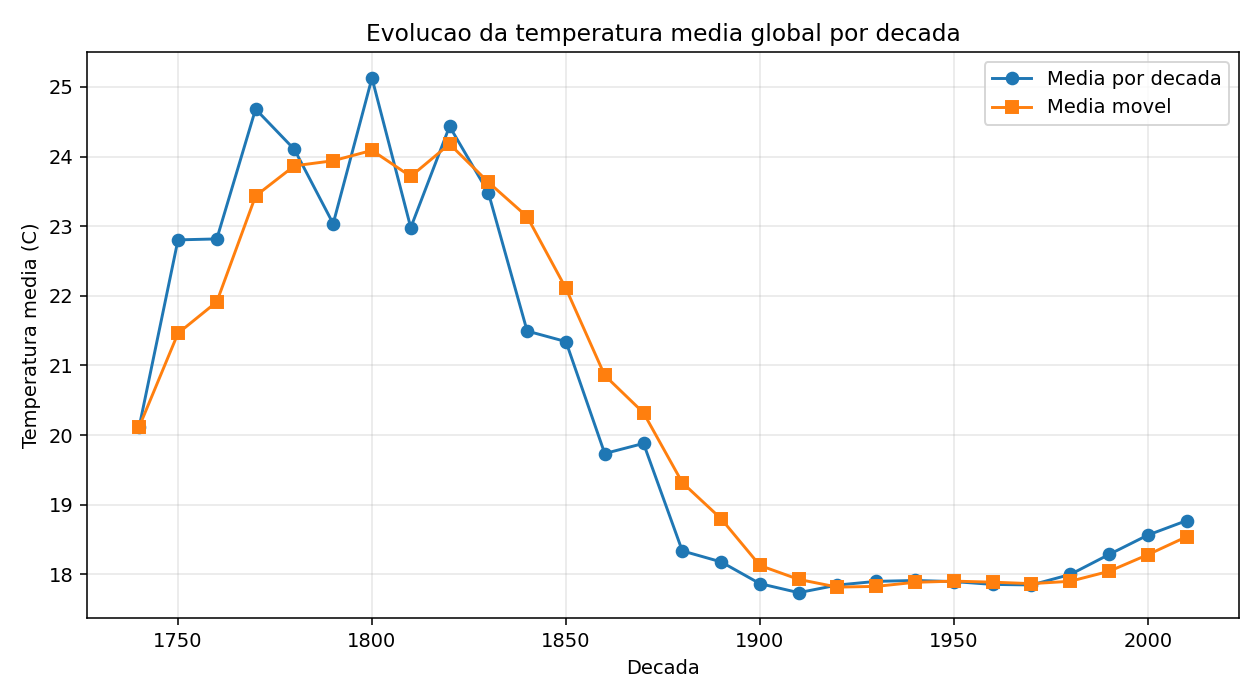

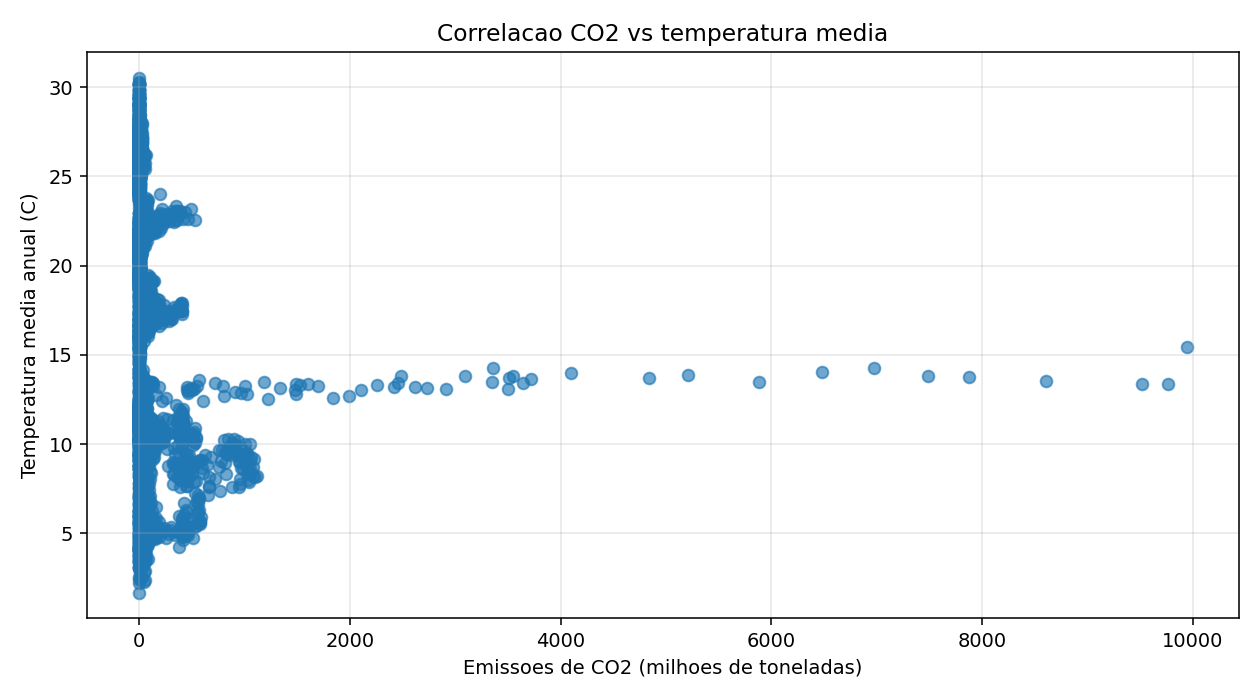

In [20]:
from IPython.display import Image, display

display(Image(filename=str(OUTPUT_DIR / "plots" / "global_decade_temperature.png")))
display(Image(filename=str(OUTPUT_DIR / "plots" / "co2_temperature_scatter.png")))


## 13. Spark UI: o que mostrar para provar

URLs:

| Modo | URL |
|---|---|
| Docker local | `http://localhost:18080` |
| 2 PCs | `http://<IP_DO_PC1>:8080` |

O que abrir na UI:

| Aba | O que provar |
|---|---|
| Workers | Existem workers registrados |
| Running Applications | Aplicacao `climate-spark-analysis` rodou |
| Jobs | Acoes como `count`, `show` e `write` viram jobs |
| Stages | Cada job foi quebrado em etapas |
| Tasks | Cada stage foi dividido em tasks |
| Executors | Mostra onde as tasks executaram |
| Storage | Mostra DataFrames em cache |

Frase para ligar codigo, plano e UI:

```text
No codigo aparece groupBy, join e Window. No plano fisico aparece Exchange, HashAggregate, SortMergeJoin e Window. Na Spark UI isso vira jobs, stages e tasks executadas pelos workers.
```


## 14. Roteiro Docker local

Use este roteiro quando quiser demonstrar em uma unica maquina.

### Demo rapida com amostra

```bash
cd spark
scripts/local_workers_raw.sh 2
```

O que acontece:

1. Cria `output`.
2. Sobe `spark-master`, `spark-worker-1` e `spark-worker-2`.
3. Roda `spark-submit` no container `spark-app`.
4. Executa `src/climate_spark/main.py` com `--mode sample`.
5. Salva resultados em `output/results`.
6. Salva graficos em `output/plots`.
7. Abre Spark UI em `http://localhost:18080`.

### Dados reais

```bash
cd spark
scripts/local_workers_raw.sh 2
```

O que acontece a mais:

1. `scripts/setup_data.sh` extrai os CSVs reais.
2. Baixa `owid-co2-data.csv`.
3. Roda uma vez com cache ligado.
4. Roda uma vez com cache desligado.
5. Permite comparar tempos no relatorio.


## 15. Roteiro em 2 PCs

Objetivo: provar que o worker remoto aparece no cluster e executa tasks.

### PC1: preparar dados e subir master

```bash
cd spark
scripts/setup_data.sh
scripts/pc1_start_raw.sh
```

Anote o IP mostrado:

```text
Spark master URL: spark://<IP_DO_PC1>:7077
Spark UI: http://<IP_DO_PC1>:8080
```

### PC2: preparar dados e subir worker

```bash
cd spark
scripts/setup_data.sh
scripts/pc2_worker_raw.sh <IP_DO_PC1>
```

Por que `setup_data.sh` tambem no PC2:

```text
Sem HDFS, cada executor precisa enxergar os arquivos locais em /app/data. Por isso os dados ficam replicados nos PCs, e o Spark distribui o processamento em particoes e tasks.
```

### PC1: submeter o job

```bash
scripts/pc1_benchmark_raw.sh
```

Para dados reais:

```bash
scripts/pc1_benchmark_raw.sh
```

O que mostrar:

1. Spark UI em `http://<IP_DO_PC1>:8080`.
2. Worker do PC2 registrado.
3. Aplicacao `climate-spark-analysis`.
4. Jobs, stages e tasks.
5. Saidas em `output/results` e `output/plots`.


### Como mostrar os PCs trabalhando

Esta parte deve ser mostrada junto com a Spark UI em `http://<IP_DO_PC1>:8080`.

| Onde olhar | Comando ou tela | O que prova |
|---|---|---|
| PC1 terminal | `docker ps` | Master esta rodando no PC1 |
| PC2 terminal | `docker ps` | Worker esta rodando no PC2 |
| PC2 terminal | `docker logs climate-spark-worker-lan` | Worker conectou em `spark://<IP_DO_PC1>:7077` |
| Spark UI | `Workers` | O worker do PC2 aparece registrado |
| Spark UI | `Alive Workers` | Mostra quantos workers estao vivos |
| Spark UI | `Total Cores` | Mostra os cores somados do cluster |
| Spark UI | `Total Memory` | Mostra memoria somada do cluster |
| Spark UI | `Running Applications` | Mostra a aplicacao `climate-spark-analysis` |
| Spark UI | `Executors` | Mostra onde os executors estao rodando |
| Notebook | `partition_evidence.groupBy("host")` | Mostra hosts que processaram particoes |

Comandos para mostrar no PC1:

```bash
cd spark
scripts/pc1_start_raw.sh
docker ps
```

Comandos para mostrar no PC2:

```bash
cd spark
scripts/pc2_worker_raw.sh <IP_DO_PC1>
docker ps
docker logs climate-spark-worker-lan
```

Comando para submeter no PC1:

```bash
scripts/pc1_benchmark_raw.sh
```

Use `sample` ao vivo porque e rapido. Use `raw` se ja tiver testado antes e houver tempo.

Como falar:

```text
O PC1 esta com o master e o driver. O PC2 esta com um worker conectado no master do PC1. Quando o job roda, o master distribui tasks para os workers. A Spark UI mostra o worker do PC2, e a tabela por host mostra quais maquinas processaram particoes. Isso prova que o PC2 trabalhou.
```

Se a tabela por host mostrar apenas um host, ainda explique corretamente:

```text
O cluster aceitou o worker, mas esta execucao especifica pode ter usado um executor ou host para estas particoes. A prova operacional fica na Spark UI, onde o worker remoto aparece como vivo, com cores e memoria disponiveis. Para forcar mais tasks, aumente `PARTITION_COUNT` e rode com `raw`.
```


In [21]:
# Resumo por host para mostrar depois da celula partition_evidence.
# Em cluster com 2 PCs, este resumo pode mostrar mais de um host.
partition_evidence.groupBy("host").count().orderBy("host").show(truncate=False)


+----+-----+
|host|count|
+----+-----+
|riri|8    |
+----+-----+



## 16. Analise de tempo: quando cluster vale a pena

Esta parte responde uma pergunta importante da defesa: se Spark distribui processamento, quando compensa usar mais de um PC? Em outras palavras, quando vale a pena usar cluster e quantos workers fazem sentido.

O projeto mede tempo por pergunta em `main.py`, usando a funcao `timed`. Esses tempos ficam em:

```text
output/results/timings_cache_on/part-*.csv
output/results/timings_cache_off/part-*.csv
```

Esses arquivos medem principalmente o tempo das acoes Spark de cada pergunta. Eles sao bons para comparar cache ligado vs cache desligado.

Resultado medido nas perguntas Q1 a Q8:

| Caso | Soma dos tempos das perguntas | Leitura |
|---|---:|---|
| Cache ligado | 20.3530s | Reaproveita bases limpas e joins |
| Cache desligado | 118.4348s | Recalcula mais etapas |
| Ganho aproximado | 5.82x | Cache foi mais importante que adicionar outro PC nesta carga |

Para comparar um PC contra cluster LAN, usamos:

```bash
scripts/local_workers_raw.sh 2
scripts/pc1_benchmark_raw.sh
```

O script grava:

```text
output/benchmark/cluster_modes.csv
```

Colunas:

| Coluna | Significado |
|---|---|
| `run_label` | `local-compose` ou `lan-cluster` |
| `data_mode` | `sample` ou `raw` |
| `total_seconds` | Tempo total de parede, incluindo Docker, submit, leitura, execucao e escrita |
| `processamento_spark_seconds` | Soma dos tempos das perguntas medidos dentro do Spark |
| `overhead_seconds` | `total_seconds - processamento_spark_seconds` |
| `overhead_seconds` | Aproximacao do custo de rede, orquestracao, Docker, submit e escrita |

Resultado medido com base real `raw`, cache ligado e 2 workers:

| Modo | Workers | `total_seconds` | `processamento_spark_seconds` | `overhead_seconds` |
|---|---:|---:|---:|---:|
| `local-compose` | 2 workers no PC1 | 158s | 35.4613s | 122.5387s |
| `lan-cluster` | 1 worker no PC1 + 1 worker no PC2 | 188s | 43.8593s | 144.1407s |

Como explicar:

```text
O processamento foi distribuido, porque a Spark UI mostrou dois workers vivos e executores em hosts diferentes. Mesmo assim, nesta medicao, o cluster LAN nao foi mais rapido que o Compose local. O motivo e que o ganho de dividir CPU foi menor que o custo de rede, Docker, submit, shuffle, escrita e trechos seriais.
```

Ponto honesto:

```text
Sem ler event logs detalhados do Spark, nao da para separar perfeitamente rede, shuffle, serializacao, escrita e orquestracao. Por isso chamamos de overhead_seconds. A Spark UI ajuda a detalhar melhor: stages com shuffle read/write alto indicam custo de rede entre executors.
```

O que observar na Spark UI:

| Campo | Como interpretar |
|---|---|
| Workers | Quantos workers estao vivos |
| Executors | Se o job recebeu executores em mais de um host |
| Duration dos jobs | Tempo real de cada job |
| Shuffle Read | Dados recebidos de outras particoes ou executors |
| Shuffle Write | Dados enviados para reorganizar chaves |
| Input Size | Quanto foi lido dos CSVs |
| Tasks | Quanto trabalho foi dividido |

Durante os testes apareceu:

```text
WindowExec: No Partition Defined for Window operation
```

Isso quer dizer que algumas janelas foram executadas sem `partitionBy`, entao o Spark moveu dados para uma unica particao. Essa parte reduz paralelismo e explica por que mais workers podem nao diminuir o tempo.

Quando vale a pena usar cluster:

1. Quando o tempo de processamento cai mais do que o overhead sobe.
2. Quando os dados sao grandes o suficiente para manter os workers ocupados.
3. Quando ha muitas particoes e tasks para distribuir.
4. Quando o gargalo nao e so leitura local ou escrita de saida pequena.
5. Quando `shuffle` nao domina o tempo total.

Quando pode nao valer:

1. Dataset pequeno, como `sample`.
2. Poucas particoes.
3. Muito overhead de Docker e submit.
4. Rede lenta entre PCs.
5. Operacoes com muito shuffle e pouca computacao por linha.
6. Window sem particionamento, escrita com `coalesce(1)` ou graficos no driver.


       run_label data_mode  total_seconds  processamento_spark_seconds  overhead_seconds  overhead_seconds
0    lan-cluster       raw           188                43.8593          144.1407                        144.1407
1  local-compose       raw           158                35.4613          122.5387                        122.5387

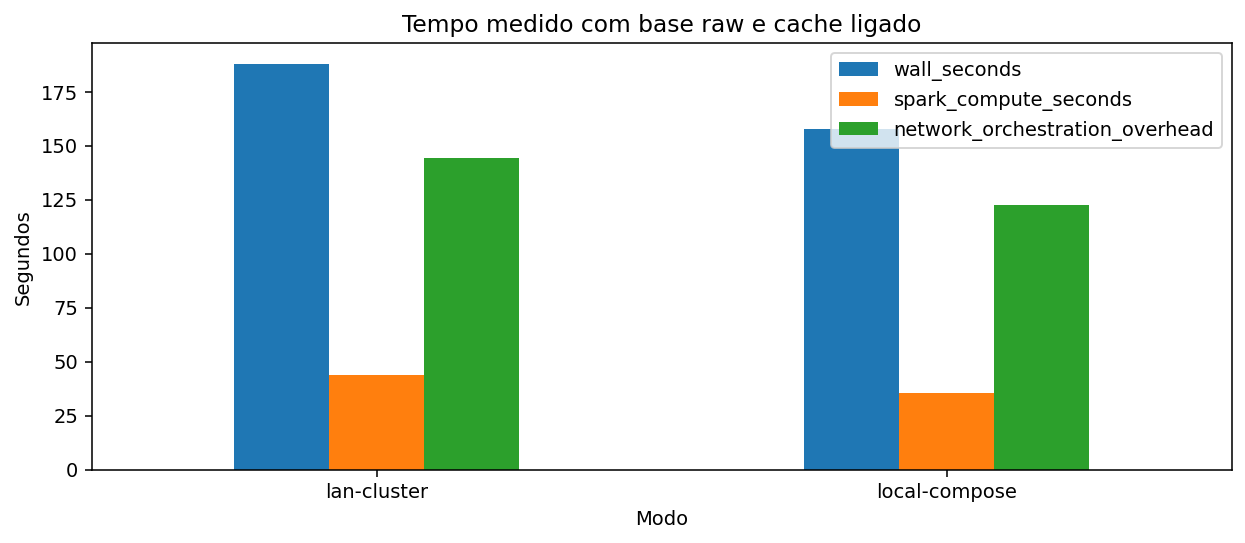

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

benchmark_path = PROJECT_ROOT / "output" / "benchmark" / "cluster_modes.csv"

if benchmark_path.exists():
    benchmark = pd.read_csv(benchmark_path)
    display(benchmark)

    ax = benchmark.plot(
        x="run_label",
        y=["total_seconds", "processamento_spark_seconds", "overhead_seconds"],
        kind="bar",
        figsize=(9, 4),
        title="Tempo medido com base raw e cache ligado",
    )
    ax.set_xlabel("Modo")
    ax.set_ylabel("Segundos")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Benchmark ainda nao coletado.")
    print("Rode:")
    print("scripts/local_workers_raw.sh 2")
    print("scripts/pc1_benchmark_raw.sh")

### Como calcular speedup e eficiencia

Depois de coletar pelo menos uma execucao local e uma execucao LAN, use:

```text
speedup = tempo_local / tempo_cluster
eficiencia = speedup / numero_de_workers
```

Com os valores medidos:

```text
speedup_lan_vs_local = 158 / 188 = 0.84
eficiencia_lan = 0.84 / 2 = 0.42
diferenca_de_overhead = 144.1407 - 122.5387 = 21.6020s
```

Interpretacao:

| Resultado | Leitura |
|---|---|
| `speedup > 1` | Cluster foi mais rapido |
| `speedup perto de 1` | Cluster nao trouxe ganho claro |
| `speedup < 1` | Cluster foi mais lento |
| `eficiencia perto de 1` | Workers bem aproveitados |
| `eficiencia baixa` | Overhead, rede, shuffle ou poucas tasks limitaram o ganho |

Neste teste, `speedup < 1`. Isso significa que o cluster LAN distribuiu processamento, mas nao reduziu o tempo total. A conclusao tecnica e boa para a defesa: Spark distribuir nao garante acelerar sempre. O ganho depende do tamanho dos dados, particionamento, custo de shuffle, rede, escrita e trabalho serial no driver.

Amdahl ajuda a explicar o limite teorico:

```text
speedup_maximo = 1 / ((1 - parte_paralelizavel) + parte_paralelizavel / workers)
```

Exemplo de fala:

```text
Se 90 por cento do trabalho e paralelizavel, 2 workers tem limite teorico de 1,82x. Com 4 workers, o limite sobe para 3,08x. Mas se a rede e o shuffle aumentarem muito, ou se parte do plano cair em uma unica particao, o ganho real fica menor.
```

Conclusao para quantos workers fazem sentido:

```text
Para este projeto, 2 workers sao suficientes para demonstrar distribuicao. Para buscar maior ganho real, primeiro aumentaria PARTITION_COUNT e revisaria as Window sem partitionBy; depois compararia 1, 2 e 4 workers olhando speedup, eficiencia e shuffle na Spark UI.
```

Conclusao a partir das medicoes:

```text
O cluster funcionou e distribuiu processamento, mas a maior melhora medida veio do cache: Q1 a Q8 cairam de 118.4348s sem cache para 20.3530s com cache. Nesta carga, reaproveitar dados intermediarios foi mais impactante do que apenas adicionar outro computador.
```


In [23]:
if benchmark_path.exists():
    benchmark = pd.read_csv(benchmark_path)
    local_rows = benchmark[benchmark["run_label"] == "local-compose"]
    cluster_rows = benchmark[benchmark["run_label"] == "lan-cluster"]
    if not local_rows.empty and not cluster_rows.empty:
        local_time = float(local_rows.iloc[-1]["total_seconds"])
        cluster_time = float(cluster_rows.iloc[-1]["total_seconds"])
        local_overhead = float(local_rows.iloc[-1]["overhead_seconds"])
        cluster_overhead = float(cluster_rows.iloc[-1]["overhead_seconds"])
        workers = 2
        speedup = local_time / cluster_time if cluster_time else 0
        eficiencia = speedup / workers if workers else 0
        overhead_delta = cluster_overhead - local_overhead

        print("tempo local:", local_time)
        print("tempo cluster LAN:", cluster_time)
        print("speedup LAN vs local:", round(speedup, 3))
        print("eficiencia LAN:", round(eficiencia, 3))
        print("diferenca de overhead:", round(overhead_delta, 4))

        if speedup < 1:
            print("Conclusao: distribuiu, mas nao acelerou nesta rodada. O overhead foi maior que o ganho de paralelismo.")
        else:
            print("Conclusao: o cluster acelerou a execucao nesta rodada.")
    else:
        print("Colete pelo menos uma linha local-compose e uma linha lan-cluster.")
else:
    print("Sem benchmark coletado ainda.")

tempo local: 158.0
tempo cluster LAN: 188.0
speedup LAN vs local: 0.84
eficiencia LAN: 0.42
diferenca de overhead: 21.602
Conclusao: distribuiu, mas nao acelerou nesta rodada. O overhead foi maior que o ganho de paralelismo.


## 17. Execucao ao vivo: tempo total, outputs e graficos

Esta secao existe para acompanhar o pipeline completo durante a apresentacao.

Ha dois tempos diferentes:

| Medida | O que significa | Onde aparece |
|---|---|---|
| Tempo por pergunta | Tempo das acoes Spark de Q1 a Q8 | `timings_cache_on` e `timings_cache_off` |
| Tempo total do pipeline | Tempo de ponta a ponta, incluindo iniciar processo, Spark, leitura, escrita e graficos | celula `LIVE_PIPELINE_COMMAND` ou `pc1_benchmark_raw.sh` ou `local_workers_raw.sh` |

Referencia medida neste ambiente:

```text
Spark local local[2], DATA_MODE=sample, cache on: 27.77 segundos de tempo total.
```

O Docker nao estava ativo neste ambiente, entao o tempo Docker deve ser medido na maquina da apresentacao. Para isso, rode:

```bash
scripts/local_workers_raw.sh 2
scripts/local_workers_raw.sh 2
```

Para comparar com 2 PCs:

```bash
scripts/pc1_benchmark_raw.sh
scripts/pc1_benchmark_raw.sh
```

Saida esperada para acompanhar:

1. A celula imprime o comando executado.
2. Mostra `pipeline_total_seconds`.
3. Mostra tabela de tempos por pergunta.
4. Mostra Grafico de tempo por pergunta.
5. Mostra os graficos finais do pipeline.

Graficos ja gerados para abrir sem executar tudo:

![Tempo por pergunta](../output/plots/timings_cache_on_barh.png)

![Temperatura por decada](../output/plots/global_decade_temperature.png)

![CO2 vs temperatura](../output/plots/co2_temperature_scatter.png)


In [24]:
import os
import subprocess
import time
from pathlib import Path

RUN_LIVE_PIPELINE = os.environ.get("RUN_LIVE_PIPELINE", "0") == "1"
LIVE_PIPELINE_OUTPUT = PROJECT_ROOT / "output_live_measure"
LIVE_PIPELINE_COMMAND = [
    sys.executable,
    str(PROJECT_ROOT / "src" / "climate_spark" / "main.py"),
    "--mode",
    "sample",
    "--cache",
    "on",
    "--master",
    "local[2]",
    "--output",
    str(LIVE_PIPELINE_OUTPUT),
]

print("LIVE_PIPELINE_COMMAND:")
print(" ".join(LIVE_PIPELINE_COMMAND))

if RUN_LIVE_PIPELINE:
    env = os.environ.copy()
    env["PYTHONPATH"] = str(PROJECT_ROOT / "src")
    start = time.perf_counter()
    result = subprocess.run(LIVE_PIPELINE_COMMAND, text=True, capture_output=True, env=env)
    pipeline_total_seconds = round(time.perf_counter() - start, 2)
    print("exit_code:", result.returncode)
    print("pipeline_total_seconds:", pipeline_total_seconds)
    print("stdout tail:")
    print(result.stdout[-2000:])
    print("stderr tail:")
    print(result.stderr[-3000:])
    if result.returncode != 0:
        raise RuntimeError("pipeline live falhou")
else:
    pipeline_total_seconds = 27.77
    print("RUN_LIVE_PIPELINE=0. Usando referencia ja medida neste ambiente.")
    print("pipeline_total_seconds:", pipeline_total_seconds)
    print("Para rodar ao vivo, mude RUN_LIVE_PIPELINE para True ou exporte RUN_LIVE_PIPELINE=1.")


LIVE_PIPELINE_COMMAND:
/home/roger/uel/sistemas-distribuidos/spark/.venv/bin/python /home/roger/uel/sistemas-distribuidos/spark/src/climate_spark/main.py --mode sample --cache on --master local[2] --output /home/roger/uel/sistemas-distribuidos/spark/output_live_measure
RUN_LIVE_PIPELINE=0. Usando referencia ja medida neste ambiente.
pipeline_total_seconds: 27.77
Para rodar ao vivo, mude RUN_LIVE_PIPELINE para True ou exporte RUN_LIVE_PIPELINE=1.


### Tabela e grafico de tempo por pergunta

Esta celula procura primeiro a saida da execucao ao vivo em `output_live_measure`. Se ela ainda nao existir, usa os resultados ja gerados em `output/results` ou `output_real`.

Como usar na fala:

```text
O tempo total mostra o custo de ponta a ponta. A tabela abaixo mostra onde o Spark gastou tempo dentro das perguntas. Se Q7 e Q8 aparecem maiores, faz sentido: Q7 usa window functions e Q8 treina MLlib.
```

Para ficar legivel na apresentacao, o grafico usa rotulos curtos `Q1` a `Q8`. A tabela ainda preserva o nome completo da pergunta.


  question_label                        question  seconds
0             Q1          q1_global_decade_trend   0.2864
1             Q2   q2_hottest_years_by_continent   0.6423
2             Q3              q3_riskiest_cities   0.2728
3             Q4          q4_min_max_correlation   0.9138
4             Q5              q5_quality_summary   0.1679
5             Q6  q6_co2_temperature_correlation   0.3912
6             Q7         q7_acceleration_ranking   2.8653
7             Q8         q8_temperature_forecast   4.5025

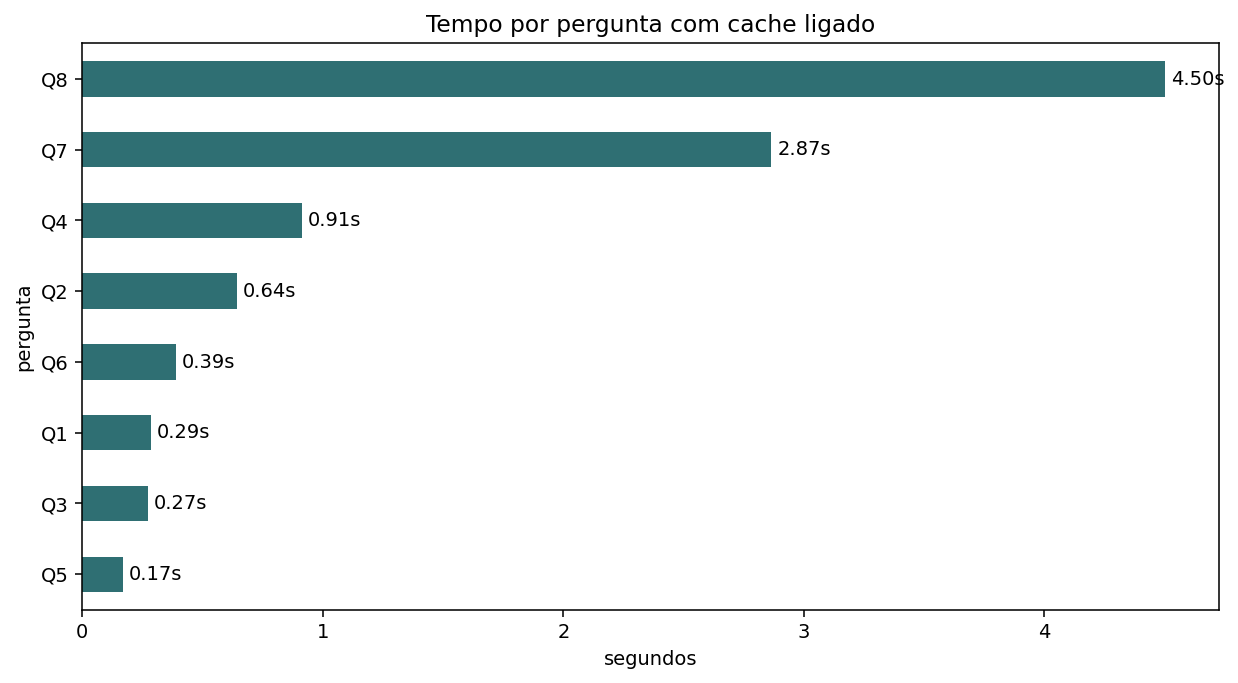

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

candidate_timing_dirs = [
    PROJECT_ROOT / "output_live_measure" / "results" / "timings_cache_on",
    PROJECT_ROOT / "output" / "results" / "timings_cache_on",
    PROJECT_ROOT / "output_real" / "results" / "timings_cache_on",
]

timing_file = None
for timing_dir in candidate_timing_dirs:
    files = sorted(timing_dir.glob("part-*.csv")) if timing_dir.exists() else []
    if files:
        timing_file = files[0]
        break

QUESTION_LABELS = {
    "q1_global_decade_trend": "Q1",
    "q2_hottest_years_by_continent": "Q2",
    "q3_riskiest_cities": "Q3",
    "q4_min_max_correlation": "Q4",
    "q5_quality_summary": "Q5",
    "q6_co2_temperature_correlation": "Q6",
    "q7_acceleration_ranking": "Q7",
    "q8_temperature_forecast": "Q8",
}

if timing_file is None:
    print("Nenhum arquivo de timing encontrado ainda.")
else:
    timings_df = pd.read_csv(timing_file)
    timings_df["question_label"] = timings_df["question"].map(QUESTION_LABELS).fillna(timings_df["question"])
    display(timings_df[["question_label", "question", "seconds"]])
    # Forma base do grafico: plot(kind="barh")
    ax = timings_df.sort_values("seconds").plot(
        kind="barh",
        x="question_label",
        y="seconds",
        legend=False,
        figsize=(9, 5),
        color="#2f6f73",
    )
    ax.set_xlabel("segundos")
    ax.set_ylabel("pergunta")
    ax.set_title("Tempo por pergunta com cache ligado")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2fs", padding=3)
    plt.tight_layout()
    plt.show()


### Graficos finais para acompanhar o resultado

Esses graficos sao gerados pelo proprio pipeline em `plotting.py`. Eles ajudam a manter a apresentacao visual enquanto o notebook explica o codigo.


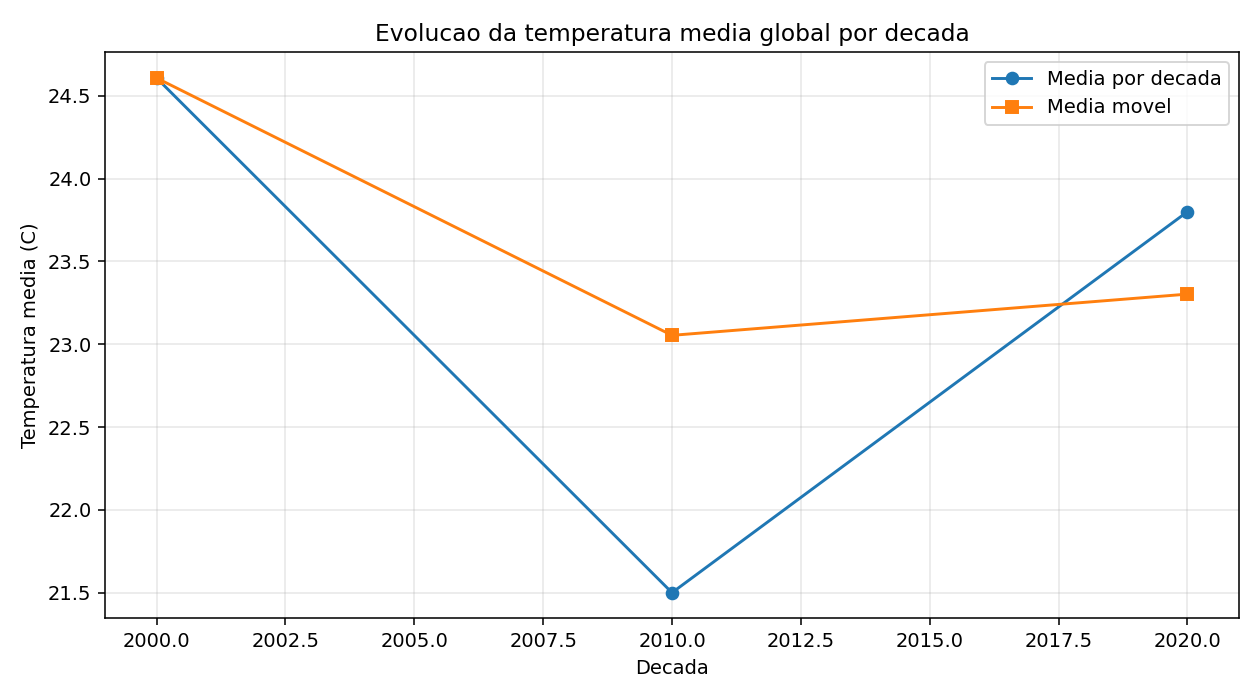

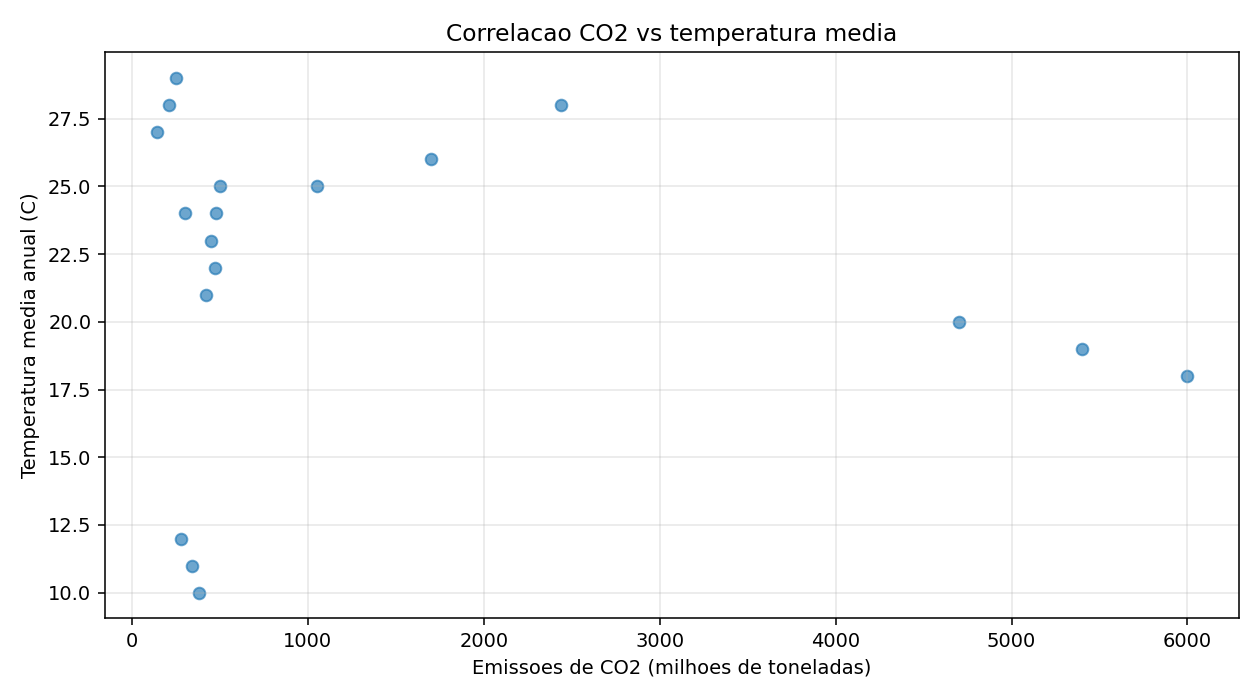

In [26]:
from IPython.display import Image, display

candidate_plot_dirs = [
    PROJECT_ROOT / "output_live_measure" / "plots",
    PROJECT_ROOT / "output" / "plots",
    PROJECT_ROOT / "output_real" / "plots",
]

plot_dir = next((path for path in candidate_plot_dirs if (path / "global_decade_temperature.png").exists()), None)
if plot_dir is None:
    print("Graficos ainda nao encontrados. Rode o pipeline primeiro.")
else:
    display(Image(filename=str(plot_dir / "global_decade_temperature.png")))
    display(Image(filename=str(plot_dir / "co2_temperature_scatter.png")))
    forecast_plot = plot_dir / "temperature_forecast_Rio_De_Janeiro_Brazil.png"
    if forecast_plot.exists():
        display(Image(filename=str(forecast_plot)))


## 18. Workers, recursos e eficiencia

O trabalho segue com 2 workers como configuracao principal. Isso e o que vamos mostrar como entrega base. A analise com 3 workers e 4 workers entra como extensao para explicar escalabilidade.

### Como testar 3 workers e 4 workers

No `docker-compose.yml` atual, existem `spark-worker-1` e `spark-worker-2`. Para 3 workers, duplique o bloco de `spark-worker-2`, crie `spark-worker-3`, troque a porta para `8083:8081` e adicione no `depends_on` do `spark-app`. Para 4 workers, crie tambem `spark-worker-4` com `8084:8081`.

Na Spark UI, verifique:

```text
Alive Workers: 3
Total Cores: soma dos cores
Total Memory: soma da memoria
```

Isso prova que os workers entraram no cluster. Para provar processamento, abra a aplicacao e confira tasks em executors diferentes.

### Mais recursos por worker

Os pontos a alterar sao os comandos dos workers:

```text
--cores 2
--memory 2G
```

Para mais recursos por worker:

```text
--cores 4
--memory 4G
```

Variaveis usadas para documentar experimentos:

```text
SPARK_WORKER_CORES
SPARK_WORKER_MEMORY
--cores ${SPARK_WORKER_CORES}
--memory ${SPARK_WORKER_MEMORY}
```

Se o Compose for refatorado para servico unico, o comando ficaria:

```bash
SPARK_WORKER_CORES=2 SPARK_WORKER_MEMORY=2G docker compose up -d --scale spark-worker=3
SPARK_WORKER_CORES=2 SPARK_WORKER_MEMORY=2G docker compose up -d --scale spark-worker=4
```

### Por que demora

O pipeline tem leitura CSV, inferencia de schema, limpeza, join, groupBy, Window, MLlib, escrita com `coalesce(1)` e graficos no driver. Mais workers ajudam quando existe trabalho paralelizavel suficiente. Nao ajudam tanto quando o gargalo e disco, shuffle, rede, driver ou escrita final.

### Eficiencia e constante de rede

Para 2, 3 e 4 workers, colete `total_seconds` e `overhead_seconds` com `scripts/pc1_benchmark_raw.sh`.

```text
speedup = tempo_2_workers / tempo_N_workers
eficiencia = speedup / (N / 2)
constante de rede aproximada = overhead_seconds
```

Se a eficiencia cair com workers adicionais, o ganho de CPU foi consumido por overhead, shuffle, disco ou rede.


## 19. Defesa tecnica curta

Use estas respostas se o professor perguntar direto.

| Pergunta | Resposta curta |
|---|---|
| Qual e o objetivo? | Apresentar o trabalho pedido pelo professor com um pipeline Spark real, distribuido, medido e explicado. |
| Onde esta a divisao? | Nas particoes dos DataFrames Spark. `repartition`, `groupBy`, `join` e `Window` reorganizam essas particoes. |
| Qual funcao divide? | A divisao e interna do Spark. No notebook, `inspect_partition` apenas mostra a divisao. |
| Como provar? | Spark UI mostra workers, executors, jobs, stages e tasks. A tabela `partition_evidence` mostra particao, host e linhas. |
| Os dados sao distribuidos? | Sem HDFS, os arquivos sao replicados nos PCs em `/app/data`; o processamento das particoes e distribuido nos workers. |
| Por que cache? | As bases limpas sao reutilizadas em varias perguntas. Cache evita recalculo e reduziu Q1 a Q8 de 118.4348s para 20.3530s. |
| Por que join por pais e ano? | Temperatura foi agregada para a mesma granularidade do CO2. |
| Por que Q4 usa proxy? | A base por cidade nao tem Tmin e Tmax reais. Usamos menor e maior media mensal anual em cidades tropicais. |
| Por que Pearson baixo na Q6? | O recorte usa CO2 anual absoluto por pais e nao controla populacao, economia, latitude ou CO2 acumulado. |
| Por que Q8 nao preve anos atuais? | A base termina antes dos anos atuais; a previsao e para os 5 anos apos o ultimo ano disponivel. |
| Por que 2 PCs nao foi mais rapido? | O cluster distribuiu, mas overhead de rede, Docker, submit, shuffle e partes seriais superou o ganho nesta carga. |

Fechamento recomendado:

```text
O trabalho mostra um pipeline Spark completo: leitura distribuida, limpeza, normalizacao, agregacoes, join entre bases, window functions, cache, MLlib, saidas em CSV e Parquet, graficos e evidencia na Spark UI. O ponto principal e que as operacoes nao rodam como loops Python locais. Elas viram planos Spark, depois jobs, stages e tasks executadas nos workers.
```
